<a href="https://colab.research.google.com/github/inaam777me/Car_Price_Model/blob/main/CarPricePredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy
import pandas as pd
import google.colab as colab
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
import matplotlib.pyplot as plt


colab.drive.mount('/content/drive/')

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')


Mounted at /content/drive/


In [6]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
x = data.drop(columns='Class', axis=1)
y = data['Class']

In [10]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [11]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [12]:
x_train,x_test,y_train,t_test=train_test_split(x,y, test_size=0.2)

In [13]:
from tensorflow.keras import callbacks

early_stopping = callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

In [21]:
model = keras.Sequential()
model.add(Dense(units=256, activation='relu', input_dim=30))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()
model.add(Dense(units=1024, activation='relu'))
layers.BatchNormalization()


model.add(Dense(units=1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['binary_accuracy']
)

In [24]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, t_test),
    batch_size=4096,
    epochs=100,
    callbacks=[early_stopping]
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - binary_accuracy: 0.9086 - loss: 509.3503 - val_binary_accuracy: 0.9983 - val_loss: 8.1198
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.9333 - loss: 54.2497 - val_binary_accuracy: 0.9983 - val_loss: 2.0117
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.9449 - loss: 18.7244 - val_binary_accuracy: 0.9983 - val_loss: 8.1254
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.9266 - loss: 59.0838 - val_binary_accuracy: 0.9983 - val_loss: 4.1681
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.9267 - loss: 29.7364 - val_binary_accuracy: 0.9983 - val_loss: 5.4173
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - binary_accuracy: 0.9447 - loss: 8.5298 - val_binary_accuracy: 0.9983 - val_loss: 0.4443
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - binary_accuracy: 0.9446 - loss: 8.3104 - val_binary_accuracy: 0.9983 - val_loss: 1.8014


Minimum validation loss: 0.0137


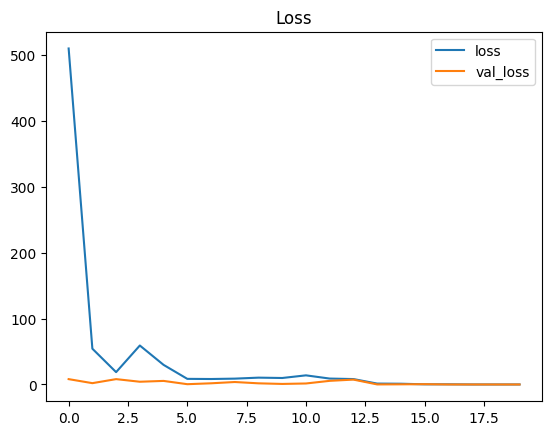

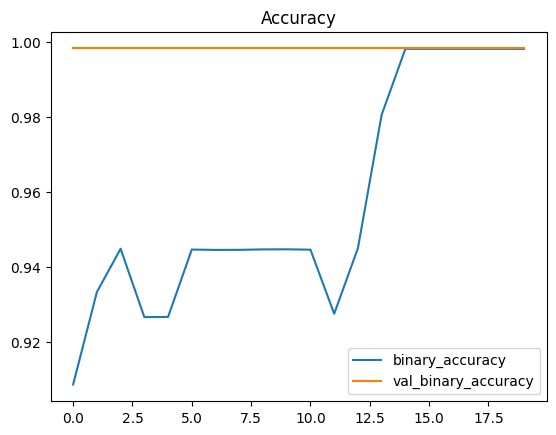

In [25]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title='Loss')
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title='Accuracy')
print("Minimum validation loss: {:0.4f}".format(history_df['val_loss'].min()));

In [20]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
y_train_pred = (y_train_pred > 0.5).astype(int).ravel()
y_test_pred = (y_test_pred > 0.5).astype(int).ravel()
print('Training accuracy:', accuracy_score(y_train, y_train_pred))
print('Test accuracy:', accuracy_score(t_test, y_test_pred))

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Training accuracy: 0.9982531984463122
Test accuracy: 0.9983497770443454


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,560,389 (63.17 MB)

 Trainable params: 5,520,129 (21.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,040,260 (42.12 MB)